# 08 - Model Evaluation

## Objective

This notebook evaluates the candidate final model selected in notebook 07 using the chronological validation window and the untouched holdout test set.

The evaluation includes probability calibration, threshold tuning, lift analysis, subgroup error analysis, final model retraining, holdout metrics, and saved model artifacts.

#### Load project configuration and modeling checkpoints

In [0]:
from __future__ import annotations

import importlib.util
from pathlib import Path

_bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not _bootstrap.is_file():
    _bootstrap = Path.cwd() / "import_path.py"
_spec = importlib.util.spec_from_file_location("import_path", _bootstrap)
_ip = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_ip)

# Load the project configuration and modeling checkpoints

import json

from config import project_config as cfg
from pyspark.sql import functions as F
from utils import model_evaluation as meval
from utils.model_training import (
    create_feature_hasher_from_manifest,
    evaluate_tuning_predictions,
    hash_modeling_frame,
    load_hist_modeling_table,
)


def require_table(table_name: str) -> None:
    if not spark.catalog.tableExists(table_name):
        raise RuntimeError(
            f"Required table '{table_name}' was not found. "
            "Run the model-training notebook (07) before continuing."
        )


def require_file(file_path: str) -> None:
    try:
        dbutils.fs.head(file_path, 1)
    except Exception as exc:
        raise RuntimeError(
            f"Required file '{file_path}' was not found. "
            "Run the model-training notebook (07) before continuing."
        ) from exc


require_file(cfg.CANDIDATE_SELECTION_PATH)
require_file(cfg.MODEL_FEATURE_MANIFEST_PATH)

candidate_selection = json.loads(
    dbutils.fs.head(cfg.CANDIDATE_SELECTION_PATH, 1000000)
)
feature_manifest = json.loads(
    dbutils.fs.head(cfg.MODEL_FEATURE_MANIFEST_PATH, 1000000)
)

TARGET_COLUMN = feature_manifest["target_column"]
CATEGORICAL_COLUMNS = list(feature_manifest["categorical_columns"])
NUMERICAL_COLUMNS = list(feature_manifest["numerical_columns"])
MODEL_INPUT_COLUMNS = list(feature_manifest["model_input_columns"])
MODELING_JOIN_KEYS = list(cfg.MODELING_JOIN_KEY_COLUMNS)
HASH_VECTOR_SIZE = int(feature_manifest["hash_vector_size"])
SELECTED_MODEL_NAME = candidate_selection["selected_model_name"]
SELECTED_MODEL_PARAMETERS = candidate_selection["selected_model_parameters"]

for table_name in [
    cfg.MODELING_TRAIN_HASHED_TABLE,
    cfg.MODELING_VALIDATION_HASHED_TABLE,
    cfg.MODELING_TEST_HASHED_TABLE,
    cfg.MODELING_TRAIN_HIST_TABLE,
    cfg.MODELING_VALIDATION_HIST_TABLE,
    cfg.MODELING_TEST_HIST_TABLE,
    cfg.TUNED_MODEL_COMPARISON_TABLE,
]:
    require_table(table_name)

# Always normalize hist tables in memory before hashing.
df_train_hist = load_hist_modeling_table(cfg.MODELING_TRAIN_HIST_TABLE)
df_validation_hist = load_hist_modeling_table(cfg.MODELING_VALIDATION_HIST_TABLE)
df_test_hist = load_hist_modeling_table(cfg.MODELING_TEST_HIST_TABLE)

feature_hasher = create_feature_hasher_from_manifest(feature_manifest)

df_train_hashed = hash_modeling_frame(df_train_hist, feature_hasher)
df_validation_hashed = hash_modeling_frame(df_validation_hist, feature_hasher)
df_test_hashed = hash_modeling_frame(df_test_hist, feature_hasher)

tuned_model_comparison = spark.table(cfg.TUNED_MODEL_COMPARISON_TABLE)
selected_model_summary = (
    tuned_model_comparison.filter(F.col("MODEL") == SELECTED_MODEL_NAME)
)

print("Modeling checkpoints loaded successfully.")
print(f"Selected model: {SELECTED_MODEL_NAME}")
print(f"Selected parameters: {SELECTED_MODEL_PARAMETERS}")
print(f"Active model input columns: {len(MODEL_INPUT_COLUMNS)}")
print(f"Feature hasher inputs: {feature_hasher.getInputCols()}")


[Truncated to first 1 bytes]
[Truncated to first 1 bytes]
Modeling checkpoints loaded successfully.
Selected model: Logistic Regression
Selected parameters: {'regParam': 0.001, 'elasticNetParam': 0.0}
Active model input columns: 24
Feature hasher inputs: ['OP_UNIQUE_CARRIER', 'ORIGIN', 'DEST', 'ORIGIN_CITY_NAME', 'ORIGIN_STATE_NM', 'DEST_CITY_NAME', 'DEST_STATE_NM', 'SEASON', 'TIME_OF_DAY', 'FLIGHT_DISTANCE_CATEGORY', 'QUARTER', 'MONTH', 'DAY_OF_WEEK', 'DISTANCE', 'CRS_DEP_TIME', 'CRS_ARR_TIME', 'CRS_ELAPSED_TIME', 'DEP_HOUR', 'DEP_MINUTE', 'IS_WEEKEND', 'AIRLINE_HIST_DELAY_RATE', 'ORIGIN_HIST_DELAY_RATE', 'DEST_HIST_DELAY_RATE', 'ROUTE_HIST_DELAY_RATE']


#### Validation-period calibration, threshold tuning, and error analysis

Before retraining on the combined training and validation periods, the selected Logistic Regression configuration is evaluated on the untouched September–October validation window. The model is trained only on the January–August training period to avoid leakage.

This section adds the probability-calibration, threshold-selection, lift, and subgroup analyses recommended for the final modeling stage.

In [0]:
import importlib.util
from pathlib import Path

_bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not _bootstrap.is_file():
    _bootstrap = Path.cwd() / "import_path.py"
_spec = importlib.util.spec_from_file_location("import_path", _bootstrap)
_ip = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_ip)

from pyspark.ml.classification import LogisticRegression
from utils import model_evaluation as meval

candidate_lr_estimator = LogisticRegression(
    featuresCol="features",
    labelCol=TARGET_COLUMN,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    regParam=SELECTED_MODEL_PARAMETERS["regParam"],
    elasticNetParam=SELECTED_MODEL_PARAMETERS["elasticNetParam"],
    maxIter=cfg.SELECTED_LR_MAX_ITER,
    standardization=True,
    family="binomial",
)

df_candidate_training_sampled = df_train_hashed.sampleBy(
    col=TARGET_COLUMN,
    fractions=cfg.TREE_TUNING_SAMPLE_FRACTIONS,
    seed=cfg.RANDOM_SEED,
)

candidate_lr_model = candidate_lr_estimator.fit(
    df_candidate_training_sampled
)

validation_predictions = candidate_lr_model.transform(
    df_validation_hashed
)

VALIDATION_PERIOD_METRICS = evaluate_tuning_predictions(validation_predictions, TARGET_COLUMN)

display(
    spark.createDataFrame(
        [
            {
                "MODEL": cfg.SELECTED_MODEL_NAME,
                "DATASET": "Chronological Validation (Sep–Oct 2025)",
                **{
                    metric_name: round(metric_value, 4)
                    for metric_name, metric_value in VALIDATION_PERIOD_METRICS.items()
                },
            }
        ]
    )
)


ACCURACY,DATASET,DELAY_F1,DELAY_PRECISION,DELAY_RECALL,F1_SCORE,MODEL,PRECISION,PR_AUC,RECALL,ROC_AUC
0.6408,Chronological Validation (Sep–Oct 2025),0.3666,0.2724,0.5605,0.6784,Logistic Regression,0.7577,0.2789,0.6408,0.6521


bin,predicted_probability,observed_rate,flight_count
0,0.09944042217843874,0.045859872611464965,785
1,0.1762991793424795,0.06345228548516439,9976
2,0.2521970948466632,0.08531061988778477,29586
3,0.33335688219394993,0.11949417803931389,39935
4,0.41790356981009236,0.16366623803400485,41994
5,0.5023597471673219,0.2117562627553881,44589
6,0.5842993516402437,0.26823781747796294,38231
7,0.6654977932297155,0.31560601064581467,21229
8,0.7427444142446162,0.35184830492242863,5221
9,0.8200668616484998,0.39086294416243655,394


Validation Brier score: 0.2167


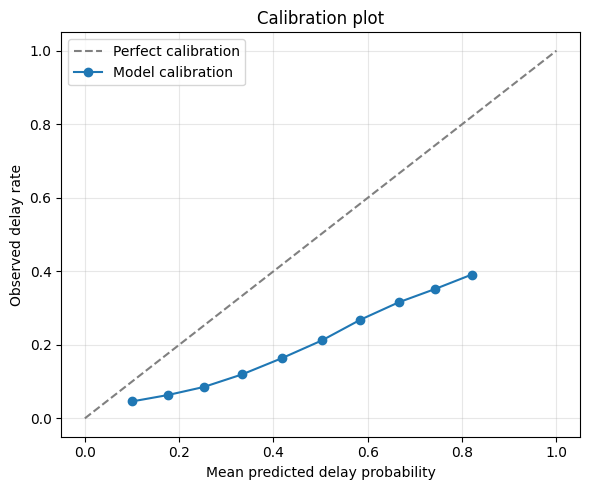

In [0]:
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt

validation_probability_frame = (
    validation_predictions
    .select(
        F.col(TARGET_COLUMN).alias("label"),
        F.element_at(vector_to_array(F.col("probability")), 2).alias("delay_probability"),
    )
    .sample(
        withReplacement=False,
        fraction=cfg.CALIBRATION_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
    .toPandas()
)

VALIDATION_BRIER_SCORE = meval.brier_score(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
)

calibration_summary = meval.calibration_summary(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)

display(calibration_summary)
print(f"Validation Brier score: {VALIDATION_BRIER_SCORE:.4f}")

calibration_figure = meval.plot_calibration_curve(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)
display(calibration_figure)
plt.close(calibration_figure)


In [0]:
threshold_results = meval.threshold_search(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    threshold_min=cfg.THRESHOLD_SEARCH_MIN,
    threshold_max=cfg.THRESHOLD_SEARCH_MAX,
    threshold_step=cfg.THRESHOLD_SEARCH_STEP,
)

display(threshold_results)

OPTIMAL_DECISION_THRESHOLD = float(
    threshold_results.sort_values("delay_f1", ascending=False).iloc[0]["threshold"]
)

lift_results = meval.lift_at_top_percentiles(
    validation_probability_frame["label"],
    validation_probability_frame["delay_probability"],
    percentiles=cfg.TOP_RISK_PERCENTILES,
)

display(lift_results)
print(f"Selected validation threshold: {OPTIMAL_DECISION_THRESHOLD:.2f}")


threshold,delay_precision,delay_recall,delay_f1
0.1,0.18658630307321664,0.9997686577522787,0.31448115267064475
0.15000000000000002,0.18759687222444751,0.9968074769814463,0.3157671027078524
0.20000000000000004,0.19161364535030015,0.9865358811826216,0.3208993972413066
0.25000000000000006,0.19972681012341642,0.9606718178873825,0.33070000796368565
0.30000000000000004,0.21121992374809104,0.9150973950862906,0.3432190889370933
0.3500000000000001,0.22509263385362935,0.8530514042474436,0.35619653888322717
0.40000000000000013,0.23968854314408103,0.7740942951001712,0.36603802481020414
0.45000000000000007,0.2555571052493942,0.6782260676444732,0.37123284201995643
0.5000000000000001,0.27325089892579774,0.5608198769259242,0.3674617069492129
0.5500000000000002,0.29311588973877906,0.42287049460972564,0.34623580554424316


top_percent,flight_count,observed_delay_rate,delay_recall,lift
0.05,11597.0,0.33793222385099597,0.09066302688196919,1.813260537639384
0.1,23194.0,0.32857635595412604,0.17630592698838662,1.763059269883866
0.2,46388.0,0.30546693110287143,0.32781196502105214,1.6390598251052608


Selected validation threshold: 0.45


In [0]:
from pyspark.ml.functions import vector_to_array

validation_scored = (
    df_validation_hist.select(
        *MODELING_JOIN_KEYS,
        *cfg.SUBGROUP_ERROR_COLUMNS,
        F.col(TARGET_COLUMN).alias("label"),
    )
    .join(
        validation_predictions.select(
            *MODELING_JOIN_KEYS,
            F.element_at(
                vector_to_array(F.col("probability")),
                2,
            ).alias("delay_probability"),
        ),
        on=MODELING_JOIN_KEYS,
        how="inner",
    )
)

subgroup_frame = validation_scored.toPandas()
subgroup_results = meval.subgroup_error_analysis(
    subgroup_frame,
    group_columns=cfg.SUBGROUP_ERROR_COLUMNS,
    label_column="label",
    probability_column="delay_probability",
    threshold=OPTIMAL_DECISION_THRESHOLD,
    min_group_size=cfg.MIN_ROUTE_FLIGHTS,
)

display(subgroup_results)


subgroup_type,subgroup_value,flight_count,delay_rate,mean_predicted_probability,delay_recall,delay_precision
DEST,ABR,137.0,0.051094890510948905,0.1706070857107348,0.0,0.0
DEST,ACK,244.0,0.18442622950819673,0.31474066327152744,0.0,0.0
DEST,APN,106.0,0.05660377358490566,0.2882775272930851,0.0,0.0
DEST,BJI,122.0,0.07377049180327869,0.20494512119620842,0.0,0.0
DEST,BRD,106.0,0.11320754716981132,0.33128165942348015,0.0,0.0
DEST,CDC,107.0,0.04672897196261682,0.14031882048039818,0.0,0.0
DEST,CLD,121.0,0.1322314049586777,0.24369542394464358,0.0,0.0
DEST,ESC,106.0,0.09433962264150944,0.2818711797152214,0.0,0.0
DEST,FOD,105.0,0.10476190476190476,0.34974852675139406,0.0,0.0
DEST,GFK,209.0,0.14354066985645933,0.22442296880157328,0.0,0.0


#### Save the selected model and supporting artifacts

The selected Logistic Regression configuration is retrained before being saved as a Spark ML model.

The final training dataset combines the original training and validation periods. This allows the selected model to learn from all historical observations available before the test period while preserving the test dataset for final holdout evaluation.

The saved artifacts will include:

- The fitted Spark ML Logistic Regression model
- The selected hyperparameters
- Model evaluation metrics
- Dataset and feature metadata

Saving these artifacts supports reproducibility and allows the model to be loaded later for batch inference, dashboard integration, and explainability analysis.


#### Rebuild historical features through October 31 for final holdout evaluation

After model and hyperparameter selection, the historical airline, origin-airport, destination-airport, and route delay-rate mappings are rebuilt using all eligible January–October 2025 outcomes.

These refreshed mappings are applied only to the November–December holdout records. No November or December outcomes are included when calculating the historical rates.

In [0]:
from pyspark.sql import DataFrame
from pyspark.sql import functions as F


# Combine January-August training and September-October validation
# outcomes for the final historical-feature mappings.
df_final_history_source = (
    df_train_hist
    .unionByName(df_validation_hist)
)

# Calculate the global delay rate through October 31, 2025.
final_global_delay_rate = (
    df_final_history_source
    .select(
        F.avg(
            F.col(TARGET_COLUMN).cast("double")
        ).alias("GLOBAL_DELAY_RATE")
    )
    .first()["GLOBAL_DELAY_RATE"]
)

FINAL_SMOOTHING_STRENGTH = float(
    cfg.HISTORICAL_SMOOTHING_STRENGTH
)


# Airline historical mapping through October 31.
final_airline_history_map = (
    df_final_history_source
    .groupBy(cfg.AIRLINE_COLUMN)
    .agg(
        F.count("*").alias("AIRLINE_FINAL_FLIGHTS"),
        F.sum(
            F.col(TARGET_COLUMN).cast("long")
        ).alias("AIRLINE_FINAL_DELAYS"),
    )
    .withColumn(
        "AIRLINE_HIST_DELAY_RATE",
        (
            F.col("AIRLINE_FINAL_DELAYS").cast("double")
            + F.lit(
                FINAL_SMOOTHING_STRENGTH
                * final_global_delay_rate
            )
        )
        /
        (
            F.col("AIRLINE_FINAL_FLIGHTS").cast("double")
            + F.lit(FINAL_SMOOTHING_STRENGTH)
        ),
    )
    .select(
        cfg.AIRLINE_COLUMN,
        "AIRLINE_HIST_DELAY_RATE",
    )
)


# Origin-airport historical mapping through October 31.
final_origin_history_map = (
    df_final_history_source
    .groupBy(cfg.ORIGIN_COLUMN)
    .agg(
        F.count("*").alias("ORIGIN_FINAL_FLIGHTS"),
        F.sum(
            F.col(TARGET_COLUMN).cast("long")
        ).alias("ORIGIN_FINAL_DELAYS"),
    )
    .withColumn(
        "ORIGIN_HIST_DELAY_RATE",
        (
            F.col("ORIGIN_FINAL_DELAYS").cast("double")
            + F.lit(
                FINAL_SMOOTHING_STRENGTH
                * final_global_delay_rate
            )
        )
        /
        (
            F.col("ORIGIN_FINAL_FLIGHTS").cast("double")
            + F.lit(FINAL_SMOOTHING_STRENGTH)
        ),
    )
    .select(
        cfg.ORIGIN_COLUMN,
        "ORIGIN_HIST_DELAY_RATE",
    )
)


# Destination-airport historical mapping through October 31.
final_destination_history_map = (
    df_final_history_source
    .groupBy(cfg.DESTINATION_COLUMN)
    .agg(
        F.count("*").alias("DEST_FINAL_FLIGHTS"),
        F.sum(
            F.col(TARGET_COLUMN).cast("long")
        ).alias("DEST_FINAL_DELAYS"),
    )
    .withColumn(
        "DEST_HIST_DELAY_RATE",
        (
            F.col("DEST_FINAL_DELAYS").cast("double")
            + F.lit(
                FINAL_SMOOTHING_STRENGTH
                * final_global_delay_rate
            )
        )
        /
        (
            F.col("DEST_FINAL_FLIGHTS").cast("double")
            + F.lit(FINAL_SMOOTHING_STRENGTH)
        ),
    )
    .select(
        cfg.DESTINATION_COLUMN,
        "DEST_HIST_DELAY_RATE",
    )
)


# Route historical mapping through October 31.
final_route_history_map = (
    df_final_history_source
    .groupBy(
        cfg.ORIGIN_COLUMN,
        cfg.DESTINATION_COLUMN,
    )
    .agg(
        F.count("*").alias("ROUTE_FINAL_FLIGHTS"),
        F.sum(
            F.col(TARGET_COLUMN).cast("long")
        ).alias("ROUTE_FINAL_DELAYS"),
    )
    .withColumn(
        "ROUTE_HIST_DELAY_RATE",
        (
            F.col("ROUTE_FINAL_DELAYS").cast("double")
            + F.lit(
                FINAL_SMOOTHING_STRENGTH
                * final_global_delay_rate
            )
        )
        /
        (
            F.col("ROUTE_FINAL_FLIGHTS").cast("double")
            + F.lit(FINAL_SMOOTHING_STRENGTH)
        ),
    )
    .select(
        cfg.ORIGIN_COLUMN,
        cfg.DESTINATION_COLUMN,
        "ROUTE_HIST_DELAY_RATE",
    )
)


def attach_final_history(dataset: DataFrame) -> DataFrame:
    """Attach January-October mappings to final holdout records."""
    return (
        dataset
        .join(
            final_airline_history_map,
            on=cfg.AIRLINE_COLUMN,
            how="left",
        )
        .join(
            final_origin_history_map,
            on=cfg.ORIGIN_COLUMN,
            how="left",
        )
        .join(
            final_destination_history_map,
            on=cfg.DESTINATION_COLUMN,
            how="left",
        )
        .join(
            final_route_history_map,
            on=[
                cfg.ORIGIN_COLUMN,
                cfg.DESTINATION_COLUMN,
            ],
            how="left",
        )
        .fillna(
            {
                "AIRLINE_HIST_DELAY_RATE":
                    final_global_delay_rate,
                "ORIGIN_HIST_DELAY_RATE":
                    final_global_delay_rate,
                "DEST_HIST_DELAY_RATE":
                    final_global_delay_rate,
                "ROUTE_HIST_DELAY_RATE":
                    final_global_delay_rate,
            }
        )
    )


# Apply refreshed mappings to untouched November-December rows.
df_test_base = df_test_hist.drop(
    *cfg.MODEL_HISTORICAL_RATE_COLUMNS
)

df_test_hist_final = attach_final_history(df_test_base)

print(
    "Final historical mapping source rows: "
    f"{df_final_history_source.count():,}"
)
print(
    "Final holdout rows after refreshed mappings: "
    f"{df_test_hist_final.count():,}"
)
print(
    "Final global delay rate through October 31: "
    f"{final_global_delay_rate:.6f}"
)

Final historical mapping source rows: 5,752,264
Final holdout rows after refreshed mappings: 1,127,220
Final global delay rate through October 31: 0.220323


#### Train the Final Selected Model Using the Tuning Sampling Strategy

The selected Logistic Regression configuration is trained using the combined training and validation periods while preserving the same stratified sampling strategy used during chronological hyperparameter tuning.

The on-time class is sampled at 10%, while the delayed-flight class is sampled at 30%. This maintains consistency between model selection and final training and reduces the tendency of the model to predict nearly all observations as on-time.

The untouched test dataset remains unsampled and is used only for final holdout evaluation.


In [0]:
import importlib.util
from pathlib import Path

_bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not _bootstrap.is_file():
    _bootstrap = Path.cwd() / "import_path.py"
_spec = importlib.util.spec_from_file_location("import_path", _bootstrap)
_ip = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_ip)

from pyspark.ml.classification import LogisticRegression
from pyspark.sql import functions as F

from utils.model_training import create_feature_hasher, hash_modeling_frame


final_feature_hasher = create_feature_hasher()

df_final_training_full = hash_modeling_frame(
    df_train_hist.unionByName(df_validation_hist),
    final_feature_hasher,
)

df_final_training_sampled = (
    df_final_training_full
    .sampleBy(
        col=TARGET_COLUMN,
        fractions=cfg.TREE_TUNING_SAMPLE_FRACTIONS,
        seed=cfg.RANDOM_SEED,
    )
)

print("Sampled final-training class distribution:")

df_final_training_sampled.groupBy(
    TARGET_COLUMN
).count().orderBy(
    TARGET_COLUMN
).show()

final_logistic_regression_estimator = LogisticRegression(
    featuresCol="features",
    labelCol=TARGET_COLUMN,
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    regParam=SELECTED_MODEL_PARAMETERS["regParam"],
    elasticNetParam=SELECTED_MODEL_PARAMETERS["elasticNetParam"],
    maxIter=cfg.SELECTED_LR_MAX_ITER,
    standardization=True,
    family="binomial",
)

final_selected_model = final_logistic_regression_estimator.fit(
    df_final_training_sampled
)

print("Final sampled Logistic Regression model trained successfully.")
print(f"Selected regParam: {SELECTED_MODEL_PARAMETERS['regParam']}")
print(f"Selected elasticNetParam: {SELECTED_MODEL_PARAMETERS['elasticNetParam']}")


Sampled final-training class distribution:
+---------+------+
|ARR_DEL15| count|
+---------+------+
|        0|448236|
|        1|380264|
+---------+------+

Final sampled Logistic Regression model trained successfully.
Selected regParam: 0.001
Selected elasticNetParam: 0.0


#### Holdout test evaluation

The retrained Logistic Regression model is evaluated using the untouched November–December 2025 holdout test dataset.

Unlike the chronological validation folds used during hyperparameter tuning, the holdout dataset was never used during model development, parameter selection, or final model training. Consequently, this evaluation provides the most realistic estimate of how the selected model is expected to perform on future unseen flight records.

The same evaluation metrics used throughout the project are calculated to support direct comparison between the tuning results and the final deployment-ready model.


In [0]:
import importlib.util
from pathlib import Path

_bootstrap = Path.cwd() / "notebooks" / "import_path.py"
if not _bootstrap.is_file():
    _bootstrap = Path.cwd() / "import_path.py"
_spec = importlib.util.spec_from_file_location("import_path", _bootstrap)
_ip = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_ip)

from utils.model_training import create_feature_hasher, hash_modeling_frame

final_test_modeling = hash_modeling_frame(
    df_test_hist_final,
    create_feature_hasher(),
)

final_test_predictions = final_selected_model.transform(
    final_test_modeling
)

DEFAULT_THRESHOLD_TEST_METRICS = evaluate_tuning_predictions(final_test_predictions, TARGET_COLUMN)

display(
    spark.createDataFrame(
        [
            {
                "MODEL": "Logistic Regression",
                "DATASET": "Holdout Test",
                **{
                    metric_name: round(metric_value, 4)
                    for metric_name, metric_value
                    in DEFAULT_THRESHOLD_TEST_METRICS.items()
                },
            }
        ]
    )
)


ACCURACY,DATASET,DELAY_F1,DELAY_PRECISION,DELAY_RECALL,F1_SCORE,MODEL,PRECISION,PR_AUC,RECALL,ROC_AUC
0.6757,Holdout Test,0.3711,0.3435,0.4035,0.6842,Logistic Regression,0.6948,0.3321,0.6757,0.6329


#### Holdout evaluation at the selected operational threshold

The decision threshold selected exclusively from the untouched September–October validation period is frozen and applied to the November–December holdout probabilities. The threshold is not recalculated using holdout data.

In [0]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql import functions as F


# Apply the threshold selected only from the September-October
# validation period. It is not recalculated using holdout data.
final_test_predictions_operational = (
    final_test_predictions
    .withColumn(
        "delay_probability",
        F.element_at(
            vector_to_array(F.col("probability")),
            2,
        ),
    )
    .withColumn(
        "default_prediction",
        F.col("prediction"),
    )
    .withColumn(
        "prediction",
        F.when(
            F.col("delay_probability")
            >= F.lit(OPTIMAL_DECISION_THRESHOLD),
            F.lit(1.0),
        ).otherwise(F.lit(0.0)),
    )
)

OPERATIONAL_THRESHOLD_TEST_METRICS = evaluate_tuning_predictions(
    final_test_predictions_operational,
    TARGET_COLUMN,
)

display(
    spark.createDataFrame(
        [
            {
                "MODEL": "Logistic Regression",
                "DATASET": "Holdout Test",
                "THRESHOLD_TYPE": "Selected operational threshold",
                "DECISION_THRESHOLD": round(
                    OPTIMAL_DECISION_THRESHOLD,
                    4,
                ),
                **{
                    metric_name: round(metric_value, 4)
                    for metric_name, metric_value
                    in OPERATIONAL_THRESHOLD_TEST_METRICS.items()
                },
            }
        ]
    )
)

print(
    "Frozen validation threshold applied to holdout data: "
    f"{OPTIMAL_DECISION_THRESHOLD:.4f}"
)

ACCURACY,DATASET,DECISION_THRESHOLD,DELAY_F1,DELAY_PRECISION,DELAY_RECALL,F1_SCORE,MODEL,PRECISION,PR_AUC,RECALL,ROC_AUC,THRESHOLD_TYPE
0.6244,Holdout Test,0.45,0.4033,0.3235,0.5354,0.6495,Logistic Regression,0.7013,0.3321,0.6244,0.6329,Selected operational threshold


Frozen validation threshold applied to holdout data: 0.4500


#### Comparison of default and operational decision thresholds

The model was evaluated using both Spark's default decision threshold (0.50) and the operational threshold (0.45) selected exclusively from the September–October validation period.

Applying the operational threshold increased recall for delayed flights and improved the Delay F1-score, demonstrating that the selected threshold better supports the project's objective of identifying flights at higher risk of delay. The threshold was frozen before evaluating the November–December holdout and was not recalculated using test data.

In [0]:
threshold_comparison = spark.createDataFrame(
    [
        {
            "THRESHOLD_TYPE": "Default threshold",
            "DECISION_THRESHOLD": 0.50,
            **{
                metric_name: round(metric_value, 4)
                for metric_name, metric_value
                in DEFAULT_THRESHOLD_TEST_METRICS.items()
            },
        },
        {
            "THRESHOLD_TYPE": "Selected operational threshold",
            "DECISION_THRESHOLD": round(
                OPTIMAL_DECISION_THRESHOLD,
                4,
            ),
            **{
                metric_name: round(metric_value, 4)
                for metric_name, metric_value
                in OPERATIONAL_THRESHOLD_TEST_METRICS.items()
            },
        },
    ]
)

display(threshold_comparison)

ACCURACY,DECISION_THRESHOLD,DELAY_F1,DELAY_PRECISION,DELAY_RECALL,F1_SCORE,PRECISION,PR_AUC,RECALL,ROC_AUC,THRESHOLD_TYPE
0.6757,0.5,0.3711,0.3435,0.4035,0.6842,0.6948,0.3321,0.6757,0.6329,Default threshold
0.6244,0.45,0.4033,0.3235,0.5354,0.6495,0.7013,0.3321,0.6244,0.6329,Selected operational threshold


#### Holdout Confusion Matrices and Ranking Curves

Two confusion matrices are generated for the untouched November–December holdout set:

1. the default Spark decision threshold of 0.50;
2. the operational threshold selected using the September–October validation period.

The ROC and Precision–Recall curves are threshold-independent and are generated from the holdout delay probabilities.

Holdout visualization sample size: 225,224
Operational decision threshold: 0.4500

Default threshold confusion matrix (0.50)


actual_on_time_predicted_on_time,actual_on_time_predicted_delayed,actual_delayed_predicted_on_time,actual_delayed_predicted_delayed
131211,40909,31714,21390


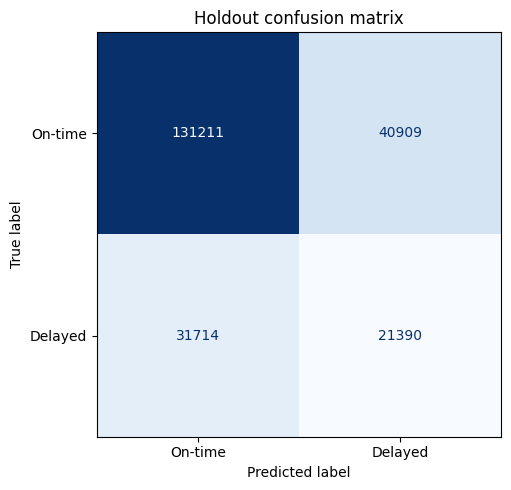


Operational threshold confusion matrix (0.4500)


actual_on_time_predicted_on_time,actual_on_time_predicted_delayed,actual_delayed_predicted_on_time,actual_delayed_predicted_delayed
112650,59470,24741,28363


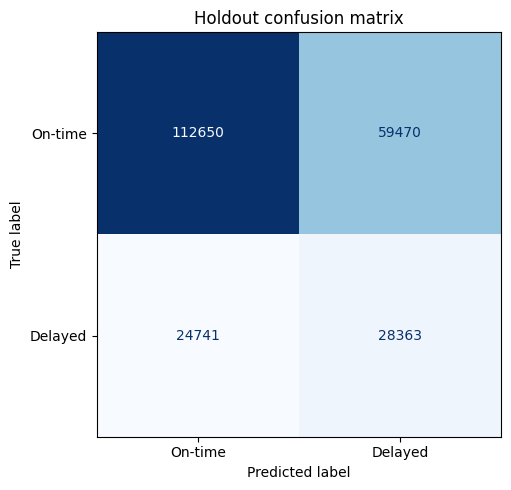

In [0]:
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt



holdout_evaluation_frame = (
    final_test_predictions
    .select(
        F.col(TARGET_COLUMN).alias("label"),
        F.col("prediction").alias(
            "default_prediction"
        ),
        F.element_at(
            vector_to_array(F.col("probability")),
            2,
        ).alias(
            "delay_probability"
        ),
    )
    .withColumn(
        "operational_prediction",
        (
            F.col("delay_probability")
            >= F.lit(OPTIMAL_DECISION_THRESHOLD)
        ).cast("double"),
    )
    .sample(
        withReplacement=False,
        fraction=cfg.CALIBRATION_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
    .toPandas()
)

print(
    f"Holdout visualization sample size: "
    f"{len(holdout_evaluation_frame):,}"
)

print(
    f"Operational decision threshold: "
    f"{OPTIMAL_DECISION_THRESHOLD:.4f}"
)



default_confusion_summary = (
    meval.confusion_matrix_summary(
        holdout_evaluation_frame["label"],
        holdout_evaluation_frame["default_prediction"],
    )
)

print("\nDefault threshold confusion matrix (0.50)")

display(
    default_confusion_summary
)

default_confusion_figure = (
    meval.plot_confusion_matrix(
        holdout_evaluation_frame["label"],
        holdout_evaluation_frame["default_prediction"],
    )
)

display(
    default_confusion_figure
)

plt.close(
    default_confusion_figure
)


operational_confusion_summary = (
    meval.confusion_matrix_summary(
        holdout_evaluation_frame["label"],
        holdout_evaluation_frame["operational_prediction"],
    )
)

print(
    "\nOperational threshold confusion matrix "
    f"({OPTIMAL_DECISION_THRESHOLD:.4f})"
)

display(
    operational_confusion_summary
)

operational_confusion_figure = (
    meval.plot_confusion_matrix(
        holdout_evaluation_frame["label"],
        holdout_evaluation_frame["operational_prediction"],
    )
)

display(
    operational_confusion_figure
)

plt.close(
    operational_confusion_figure
)

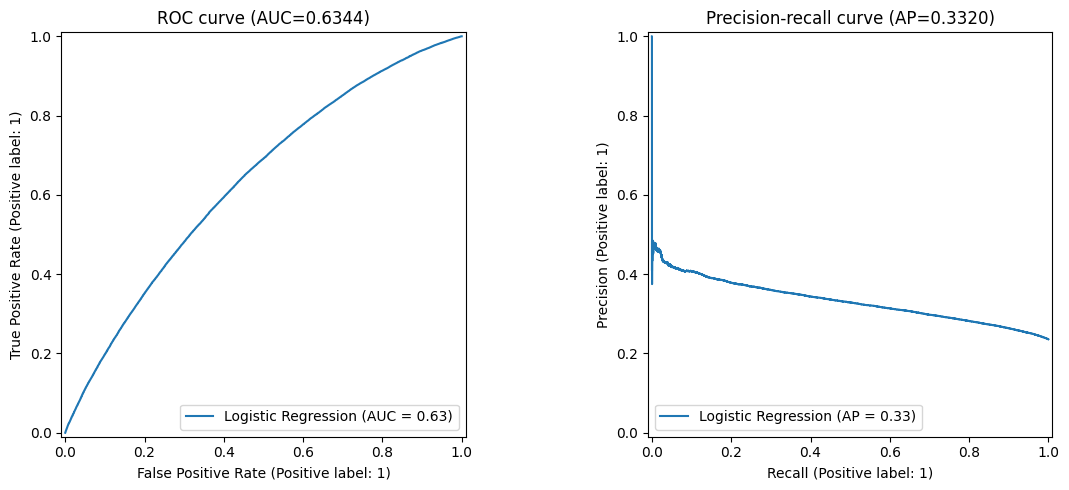

In [0]:
import matplotlib.pyplot as plt


roc_pr_figure = meval.plot_roc_pr_curves(
    holdout_evaluation_frame["label"],
    holdout_evaluation_frame["delay_probability"],
)
display(roc_pr_figure)
plt.close(roc_pr_figure)


#### Holdout calibration diagnostics

The holdout test set is evaluated once for calibration diagnostics. No threshold tuning or model changes are performed using the test window.


bin,predicted_probability,observed_rate,flight_count
0,0.09732470154889555,0.08064516129032258,1364
1,0.17219975327595244,0.10085174669793853,16202
2,0.24762868216034808,0.1421062461645188,37479
3,0.32955094054690115,0.1935778527262507,42696
4,0.41436521381731,0.2380220343325647,42933
5,0.4976406673848178,0.2886993194670756,41732
6,0.5783519149126204,0.3408957084964151,28871
7,0.6579867016454779,0.3963071758287872,11915
8,0.7352391497492582,0.46137895282529806,1929
9,0.8124819581136121,0.46601941747572817,103


Holdout Brier score: 0.2044


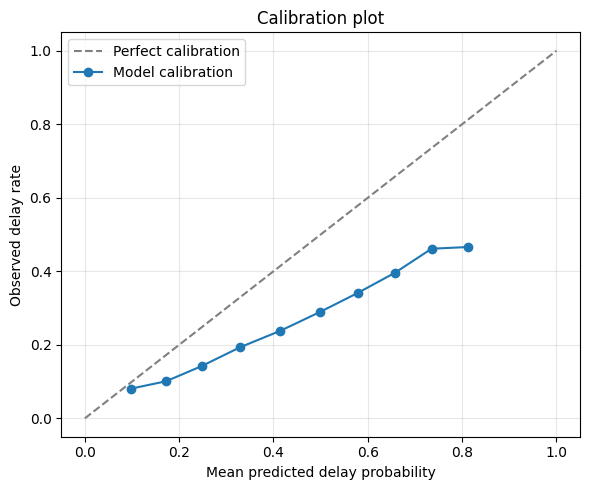

In [0]:
from pyspark.ml.functions import vector_to_array
test_probability_frame = (
    final_test_predictions
    .select(
        F.col(TARGET_COLUMN).alias("label"),
        F.element_at(vector_to_array(F.col("probability")), 2).alias("delay_probability"),
    )
    .sample(
        withReplacement=False,
        fraction=cfg.CALIBRATION_SAMPLE_FRACTION,
        seed=cfg.RANDOM_SEED,
    )
    .toPandas()
)

TEST_BRIER_SCORE = meval.brier_score(
    test_probability_frame["label"],
    test_probability_frame["delay_probability"],
)

test_calibration_summary = meval.calibration_summary(
    test_probability_frame["label"],
    test_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)

display(test_calibration_summary)
print(f"Holdout Brier score: {TEST_BRIER_SCORE:.4f}")

test_calibration_figure = meval.plot_calibration_curve(
    test_probability_frame["label"],
    test_probability_frame["delay_probability"],
    n_bins=cfg.CALIBRATION_BINS,
)
display(test_calibration_figure)
plt.close(test_calibration_figure)


#### Holdout Test Interpretation

The notebook reports two sets of holdout metrics:

- `DEFAULT_THRESHOLD_TEST_METRICS` evaluates the final Logistic Regression model using the default decision threshold of 0.50.
- `OPERATIONAL_THRESHOLD_TEST_METRICS` evaluates the same model using the operational threshold selected exclusively from the September–October validation period.

The operational-threshold metrics are treated as the official deployment results because they reflect the decision rule used by the downstream prioritization workflow.

The November–December holdout set was not used during model selection, threshold selection, or final model fitting. It therefore provides the final unbiased estimate of predictive performance.

Logistic Regression remains the selected final model based on the chronological tuning results from Notebook 07. Random Forest and Gradient-Boosted Trees are not re-evaluated on the holdout set because the holdout is reserved for the selected model only.

#### Save the Trained Spark ML Model

The retrained Logistic Regression model is saved as a native Spark ML model.

Saving the model enables future loading for batch inference, operational deployment, dashboard integration, and explainability analysis without requiring retraining.

The model is stored in the Databricks workspace using Spark ML's native persistence format.


In [0]:
from pathlib import Path

MODEL_SAVE_PATH = cfg.SELECTED_MODEL_PATH

final_selected_model.write().overwrite().save(
    MODEL_SAVE_PATH
)

print("Final model saved successfully.")
print(f"Location: {MODEL_SAVE_PATH}")

Final model saved successfully.
Location: /Volumes/workspace/default/flight_delay_capstone/models/logistic_regression_final


#### Save Model Metadata

The selected hyperparameters and evaluation metrics are saved to support reproducibility and future model maintenance.

These metadata describe the final production model without requiring the tuning process to be rerun.


In [0]:
import json

selected_metrics_row = (
    selected_model_summary
    .select(
        "MODEL",
        "PARAMETERS",
        "ACCURACY",
        "PRECISION",
        "RECALL",
        "F1_SCORE",
        "ROC_AUC",
        "PR_AUC",
        "DELAY_PRECISION",
        "DELAY_RECALL",
        "DELAY_F1",
        "TRAINING_SECONDS",
    )
    .first()
)

if selected_metrics_row is None:
    raise ValueError(
        "Selected model metadata could not be retrieved."
    )

MODEL_METADATA = {
    "model": selected_metrics_row["MODEL"],
    "target": TARGET_COLUMN,
    "parameters": SELECTED_MODEL_PARAMETERS,
    "parameter_summary": selected_metrics_row["PARAMETERS"],
    "hash_vector_size": HASH_VECTOR_SIZE,
    "categorical_features": CATEGORICAL_COLUMNS,
    "numerical_features": NUMERICAL_COLUMNS,
    "total_raw_predictors": len(MODEL_INPUT_COLUMNS),
    "selected_after_hyperparameter_tuning": True,
    "final_training_period": "January 2025 to October 2025",
    "holdout_test_period": "November 2025 to December 2025",
    "model_format": "Spark ML",
}

dbutils.fs.put(
    (
        cfg.SELECTED_MODEL_METADATA_PATH
    ),
    json.dumps(MODEL_METADATA, indent=4),
    overwrite=True,
)

print("Dynamic model metadata saved successfully.")

Wrote 1157 bytes.
Dynamic model metadata saved successfully.


#### Save Evaluation Metrics

The final evaluation metrics of the selected model are saved to provide a permanent record of the model's predictive performance.

These metrics support future model monitoring and performance comparison.


In [0]:
# Persist the deployment metrics. The operational threshold selected
# using the September-October validation period is frozen and applied
# to the untouched November-December holdout.

MODEL_METRICS = {
    # Primary deployment performance from the untouched holdout
    # using the selected operational threshold.
    "accuracy": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["ACCURACY"]
    ),
    "precision": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["PRECISION"]
    ),
    "recall": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["RECALL"]
    ),
    "f1_score": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["F1_SCORE"]
    ),
    "roc_auc": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["ROC_AUC"]
    ),
    "pr_auc": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["PR_AUC"]
    ),
    "delay_precision": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["DELAY_PRECISION"]
    ),
    "delay_recall": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["DELAY_RECALL"]
    ),
    "delay_f1": float(
        OPERATIONAL_THRESHOLD_TEST_METRICS["DELAY_F1"]
    ),

    "metric_source": (
        "Untouched November-December 2025 holdout test set "
        "evaluated using the frozen operational threshold"
    ),

    # Threshold and calibration information.
    "default_decision_threshold": 0.50,
    "selected_validation_threshold": float(
        OPTIMAL_DECISION_THRESHOLD
    ),
    "validation_brier_score": float(
        VALIDATION_BRIER_SCORE
    ),
    "holdout_brier_score": float(
        TEST_BRIER_SCORE
    ),

    # Preserve tuning metrics separately for model-selection history.
    "tuning_validation_metrics": {
        "accuracy": float(
            selected_metrics_row["ACCURACY"]
        ),
        "precision": float(
            selected_metrics_row["PRECISION"]
        ),
        "recall": float(
            selected_metrics_row["RECALL"]
        ),
        "f1_score": float(
            selected_metrics_row["F1_SCORE"]
        ),
        "roc_auc": float(
            selected_metrics_row["ROC_AUC"]
        ),
        "pr_auc": float(
            selected_metrics_row["PR_AUC"]
        ),
        "delay_precision": float(
            selected_metrics_row["DELAY_PRECISION"]
        ),
        "delay_recall": float(
            selected_metrics_row["DELAY_RECALL"]
        ),
        "delay_f1": float(
            selected_metrics_row["DELAY_F1"]
        ),
        "average_training_seconds": float(
            selected_metrics_row["TRAINING_SECONDS"]
        ),
    },

    # Holdout performance using Spark's default threshold of 0.50.
    "default_threshold_metrics": {
        metric_name.lower(): float(metric_value)
        for metric_name, metric_value
        in DEFAULT_THRESHOLD_TEST_METRICS.items()
    },

    # Official deployment holdout performance using the selected
    # operational threshold.
    "operational_threshold_metrics": {
        metric_name.lower(): float(metric_value)
        for metric_name, metric_value
        in OPERATIONAL_THRESHOLD_TEST_METRICS.items()
    },
}

dbutils.fs.put(
    cfg.SELECTED_MODEL_METRICS_PATH,
    json.dumps(MODEL_METRICS, indent=4),
    overwrite=True,
)

print(
    "Final holdout evaluation metrics saved successfully "
    "using the operational decision threshold."
)

Wrote 1815 bytes.
Final holdout evaluation metrics saved successfully using the operational decision threshold.


In [0]:
print("Original holdout rows:", df_test_hist.count())
print("Refreshed holdout rows:", df_test_hist_final.count())

Original holdout rows: 1127220
Refreshed holdout rows: 1127220


In [0]:
display(
    df_test_hist_final.select(
        cfg.AIRLINE_COLUMN,
        cfg.ORIGIN_COLUMN,
        cfg.DESTINATION_COLUMN,
        "AIRLINE_HIST_DELAY_RATE",
        "ORIGIN_HIST_DELAY_RATE",
        "DEST_HIST_DELAY_RATE",
        "ROUTE_HIST_DELAY_RATE",
    ).limit(10)
)

OP_UNIQUE_CARRIER,ORIGIN,DEST,AIRLINE_HIST_DELAY_RATE,ORIGIN_HIST_DELAY_RATE,DEST_HIST_DELAY_RATE,ROUTE_HIST_DELAY_RATE
AA,JFK,LAX,0.2586031993451762,0.23983032132529417,0.1828680543485577,0.19361258124199462
AA,LAX,JFK,0.2586031993451762,0.16821105011478518,0.22389232917325422,0.1876950201871452
AA,PVD,ORD,0.2586031993451762,0.21039663067595854,0.24293052420982572,0.24592949227813632
AA,DEN,MIA,0.2586031993451762,0.266749196270254,0.23237773555164945,0.2782636362440197
AA,BOS,CLT,0.2586031993451762,0.23686020287143017,0.19555178387326552,0.20089190992007727
AA,DFW,SFO,0.2586031993451762,0.2898811732450327,0.23233219639452105,0.3285599653148931
AA,MIA,LAS,0.2586031993451762,0.2647384889195364,0.20919915834602704,0.2755307918050765
AA,DFW,MSY,0.2586031993451762,0.2898811732450327,0.23121781503472336,0.335637800869535
AA,ATL,DFW,0.2586031993451762,0.24093544931875038,0.250581569257396,0.296275001203889
AA,DFW,ATL,0.2586031993451762,0.2898811732450327,0.18799400111938996,0.25847816111931854
